<a href="https://colab.research.google.com/github/Madhuanabala/deepak-bhaiya_new/blob/classification-models-rdkit/QD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Model: Quadratic Discriminant Analysis (No Sampling)
Accuracy: 0.8178571428571428
Balanced Accuracy: 0.785014005602241
ROC AUC: 0.844937975190076
F1 Score: 0.5486725663716814
Cohen's Kappa: 0.4438386041439477
Mean Absolute Error: 0.18214285714285713

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.83      0.89       238
           1       0.44      0.74      0.55        42

    accuracy                           0.82       280
   macro avg       0.69      0.79      0.72       280
weighted avg       0.87      0.82      0.84       280



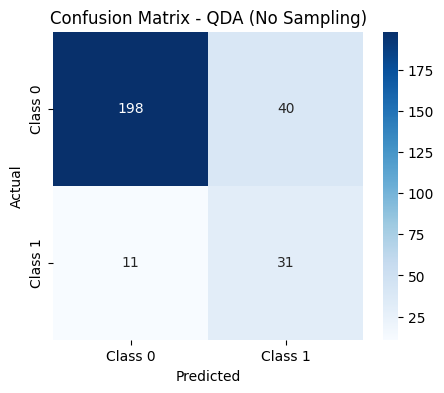

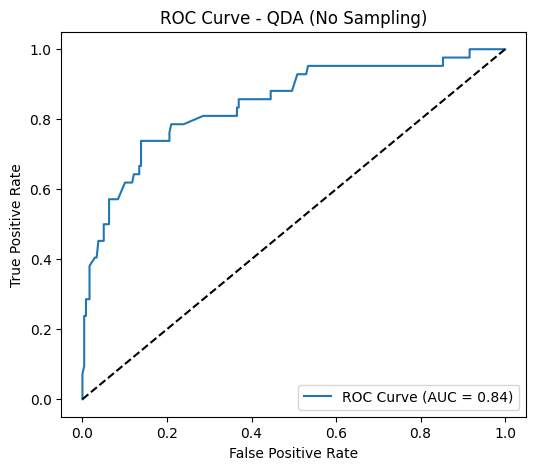

In [1]:
!pip install matplotlib seaborn scikit-learn

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, roc_auc_score, f1_score,
    classification_report, confusion_matrix, cohen_kappa_score, mean_absolute_error,
    roc_curve
)
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.preprocessing import LabelEncoder


df = pd.read_csv("/content/MACCS2_Trainset_top20.csv")


X = df.drop(columns=["BioactivityClass"])
y = df["BioactivityClass"]


if y.dtype == 'object':
    le = LabelEncoder()
    y = le.fit_transform(y)


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)


model = QuadraticDiscriminantAnalysis()
model.fit(X_train, y_train)


y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]


print("Model: Quadratic Discriminant Analysis (No Sampling)")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_prob))
print("F1 Score:", f1_score(y_test, y_pred))
print("Cohen's Kappa:", cohen_kappa_score(y_test, y_pred))
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Class 0', 'Class 1'],
            yticklabels=['Class 0', 'Class 1'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - QDA (No Sampling)')
plt.show()


fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc_score(y_test, y_prob):.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - QDA (No Sampling)')
plt.legend(loc='lower right')
plt.show()

In [4]:

metrics = {
    "Accuracy": [accuracy_score(y_test, y_pred)],
    "Balanced Accuracy": [balanced_accuracy_score(y_test, y_pred)],
    "ROC AUC": [roc_auc_score(y_test, y_prob)],
    "F1 Score": [f1_score(y_test, y_pred)],
    "Cohen's Kappa": [cohen_kappa_score(y_test, y_pred)],
    "Mean Absolute Error": [mean_absolute_error(y_test, y_pred)],
}

df_metrics = pd.DataFrame(metrics)
df_metrics.to_excel("QDA_NoSampling_metrics.xlsx", index=False)
print("\nMetrics saved to 'QDA_NoSampling_metrics.xlsx'")


from collections import Counter
pred_counts = Counter(y_pred)
print("\nPredicted class distribution:", pred_counts)


df_pred_counts = pd.DataFrame.from_dict(pred_counts, orient="index", columns=["Count"])
df_pred_counts.to_excel("QDA_NoSampling_pred_counts.xlsx")
print("Prediction counts saved to 'QDA_NoSampling_pred_counts.xlsx'")




Metrics saved to 'QDA_NoSampling_metrics.xlsx'

Predicted class distribution: Counter({np.int64(0): 209, np.int64(1): 71})
Prediction counts saved to 'QDA_NoSampling_pred_counts.xlsx'
